# Plot Styling Guide

Every visual choice in OpenRetailScience plots is exposed as a configurable option under the `plot.*` namespace: colors, fonts, spacing, spines, grids, legends, and cell decorations. This page walks through every group and shows the visual effect of each.

The four groups:

- **`plot.color.*`**: semantic colors (positive/negative), chrome colors (title/source), and series palettes (mono/multi/venn)
- **`plot.font.*`**: font family and size for every text role (title, eyebrow, label, tick, legend, source, data label)
- **`plot.spacing.*`**: padding around axis labels
- **`plot.style.*`**: background, grid, spines, legend position, cell decorations

## How to override

```python
from openretailscience.options import set_option, option_context

# Globally for the rest of the run
set_option("plot.color.primary", "#0ea5e9")

# Temporarily, scoped to a `with` block (alternating name, value pairs)
with option_context("plot.color.primary", "#0ea5e9", "plot.font.title_size", 18):
    ax = bar.plot(df, value_col="unit_spend", title="Sky-blue title")
```

You can also set options globally via an `openretailscience.toml` file at the project root: see the [Options & Configuration](../options_guide/) guide for full mechanics.

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openretailscience.constants import COLORS
from openretailscience.options import get_option, option_context
from openretailscience.plots import bar, heatmap, line
from openretailscience.plots.styles.font_utils import get_font_properties
from openretailscience.plots.styles.graph_utils import set_axis_shorthand


def shorthand(ax, prefix="$"):
    set_axis_shorthand(ax.yaxis, prefix=prefix)


BUNDLED_FONTS = [
    "poppins_regular",
    "poppins_medium",
    "poppins_semi_bold",
    "poppins_bold",
    "poppins_light_italic",
]

rng = np.random.default_rng(7)

# ---- Shared retail data used across the demos ----
sales = pd.DataFrame(
    {
        "store": ["North", "South", "East", "West", "Central"],
        "spend": [142_000, 128_500, 156_200, 119_800, 168_400],
    }
)

grouped = (
    pd.DataFrame(
        {
            "store": ["North", "South", "East", "West"] * 3,
            "channel": ["Online"] * 4 + ["In-store"] * 4 + ["Pickup"] * 4,
            "spend": [62_000, 58_400, 71_300, 49_900, 80_500, 72_100, 86_600, 64_300, 22_400, 19_800, 27_500, 17_900],
        }
    )
    .pivot(index="store", columns="channel", values="spend")
    .reset_index()
)

monthly = pd.DataFrame(
    {
        "month": pd.date_range("2024-01-01", periods=12, freq="MS"),
        "spend": rng.integers(115_000, 175_000, 12),
    }
)


# ---- Helpers for the swatch / font / palette renders ----
def hue_grid(hues, shades=(100, 300, 500, 700, 900)):
    fig, ax = plt.subplots(figsize=(len(shades) * 1.6 + 1.4, len(hues) * 0.85))
    for r, hue in enumerate(hues):
        ax.text(-0.1, r + 0.45, hue, ha="right", va="center", fontsize=11, weight="bold")
        for c, shade in enumerate(shades):
            color = COLORS[hue][shade]
            ax.add_patch(mpatches.Rectangle((c + 0.02, r + 0.05), 0.96, 0.85, color=color))
            text_color = "white" if shade >= 500 else "#1f2937"
            ax.text(
                c + 0.5, r + 0.32, str(shade), ha="center", va="center", fontsize=10, color=text_color, weight="bold"
            )
            ax.text(
                c + 0.5, r + 0.62, color, ha="center", va="center", fontsize=8, family="monospace", color=text_color
            )
    ax.set_xlim(-0.05, len(shades))
    ax.set_ylim(0, len(hues))
    ax.invert_yaxis()
    ax.axis("off")
    plt.tight_layout()
    return fig


def labeled_swatches(items, ncols=2, fig_w=12, row_h=0.85):
    rows = (len(items) + ncols - 1) // ncols
    fig, ax = plt.subplots(figsize=(fig_w, rows * row_h))
    for idx, (label, color, desc) in enumerate(items):
        r, c = divmod(idx, ncols)
        x0 = c * (fig_w / ncols)
        ax.add_patch(mpatches.Rectangle((x0 + 0.05, r + 0.15), 0.7, 0.7, color=color))
        ax.text(x0 + 0.95, r + 0.30, label, va="center", fontsize=11, weight="bold")
        ax.text(x0 + 0.95, r + 0.58, color, va="center", fontsize=9, family="monospace", color="#6b7280")
        ax.text(x0 + 0.95, r + 0.85, desc, va="center", fontsize=9, color="#374151")
    ax.set_xlim(0, fig_w)
    ax.set_ylim(0, rows)
    ax.invert_yaxis()
    ax.axis("off")
    plt.tight_layout()
    return fig


def palette_strip(palette, label):
    fig, ax = plt.subplots(figsize=(max(len(palette) * 0.4, 6), 1.1))
    for i, c in enumerate(palette):
        ax.add_patch(mpatches.Rectangle((i, 0), 1, 1, color=c))
    ax.set_xlim(0, len(palette))
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(label, fontsize=13, loc="left", pad=6, weight="semibold")
    plt.tight_layout()
    return fig

## Chrome

"Chrome" is the text and decoration *around* the data: the main title, an optional small uppercase eyebrow above it, an optional subtitle below it, the small green tab mark, and a source attribution at the bottom. Chrome elements are opt-in via plot-function arguments (`title=...`, `subtitle=...`, etc.); the colors and fonts they render in come from the option system.

<div class="admonition note">
  <p class="admonition-title">Subplots and chrome</p>
  <p>Title, eyebrow, subtitle, source text, and the tab mark are positioned in figure coordinates rather than axes coordinates. Putting two chrome-bearing OpenRetailScience plots into the same figure with <code>plt.subplots(1, 2, ...)</code> will misalign their chrome. Render each chrome-bearing plot in its own figure — every demo on this page does so.</p>
</div>

Here are all five rendered in a single annotated plot:

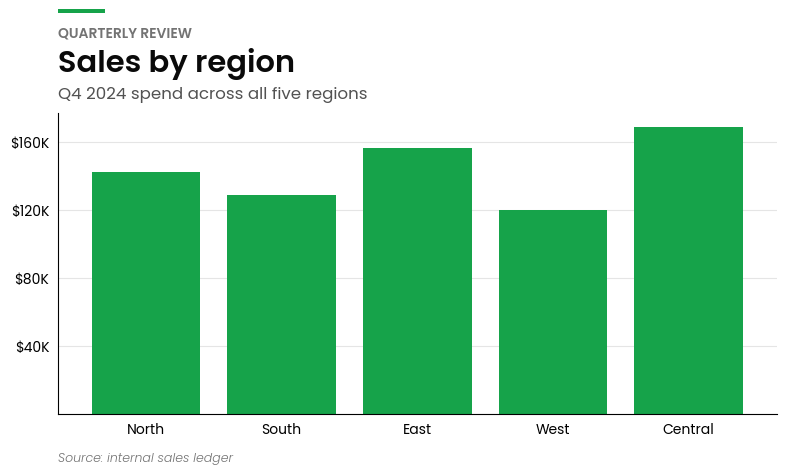

In [ ]:
ax = bar.plot(
    sales,
    x_col="store",
    value_col="spend",
    eyebrow="QUARTERLY REVIEW",
    title="Sales by region",
    subtitle="Q4 2024 spend across all five regions",
    source_text="Source: internal sales ledger",
    figsize=(8, 5),
)
shorthand(ax)
plt.show()

### Variants

The same bar chart with progressively more chrome turned on. Every chrome element is independent: turn on whichever the situation calls for.

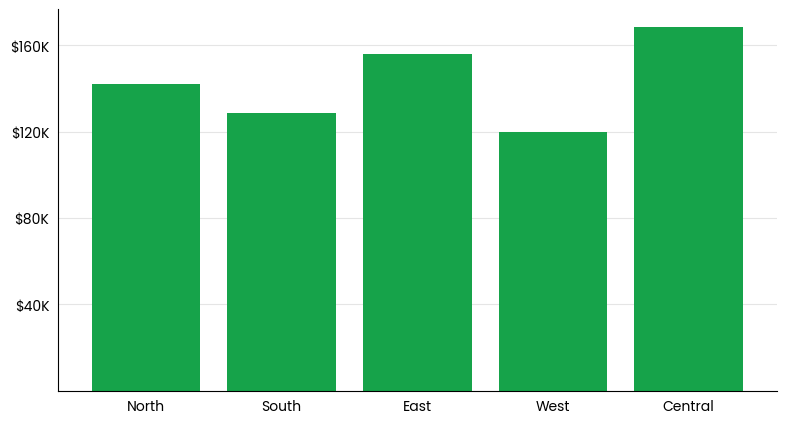

In [ ]:
ax = bar.plot(sales, x_col="store", value_col="spend", figsize=(8, 4.5))
shorthand(ax)
plt.show()

**`title` only**, the most common case for in-line analytics:

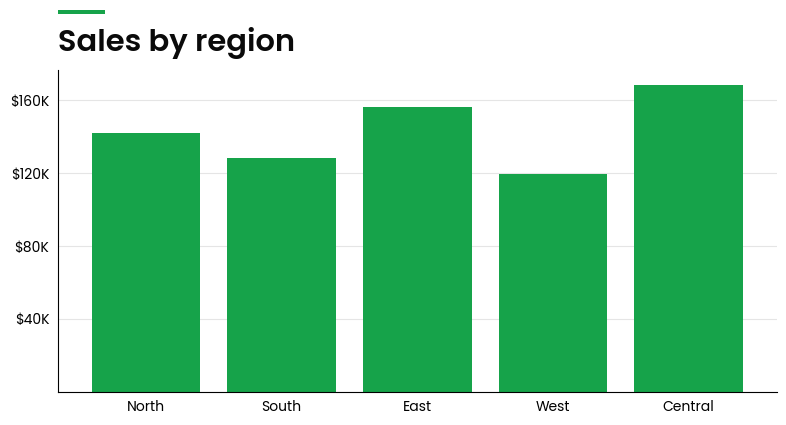

In [ ]:
ax = bar.plot(sales, x_col="store", value_col="spend", title="Sales by region", figsize=(8, 4.5))
shorthand(ax)
plt.show()

**`title` + `subtitle`**, useful for adding the time period or the metric definition:

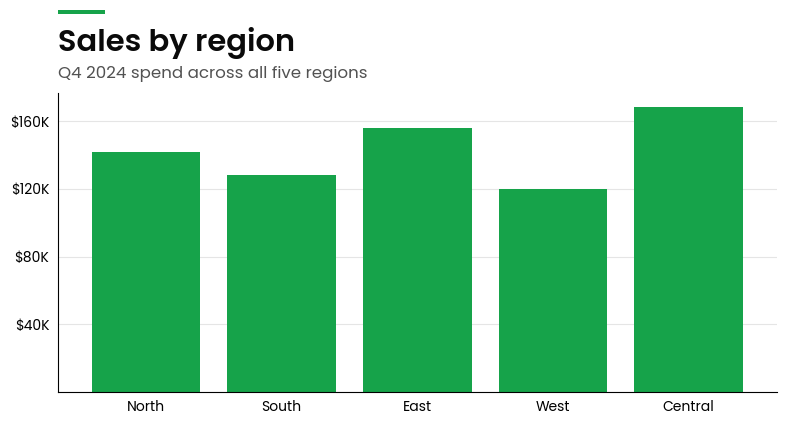

In [ ]:
ax = bar.plot(
    sales,
    x_col="store",
    value_col="spend",
    title="Sales by region",
    subtitle="Q4 2024 spend across all five regions",
    figsize=(8, 4.5),
)
shorthand(ax)
plt.show()

**`title` + `eyebrow`**, where the eyebrow orients the reader to the broader topic above the headline:

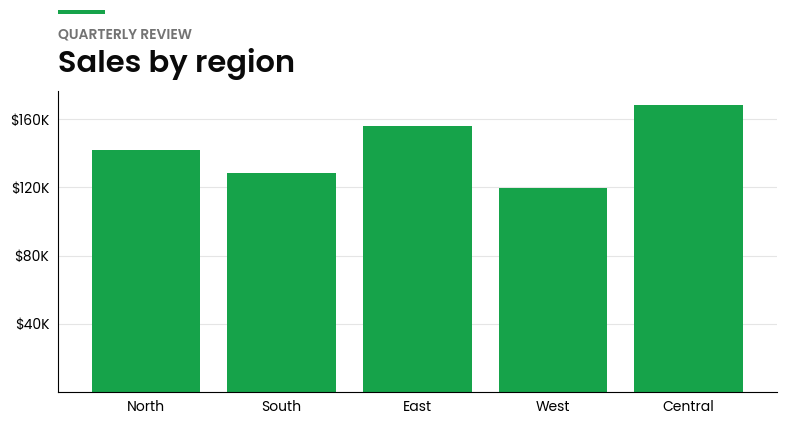

In [ ]:
ax = bar.plot(
    sales, x_col="store", value_col="spend", title="Sales by region", eyebrow="QUARTERLY REVIEW", figsize=(8, 4.5)
)
shorthand(ax)
plt.show()

**Full chrome**, eyebrow + tab + title + subtitle + source. Use this for charts that ship to stakeholders or appear in decks:

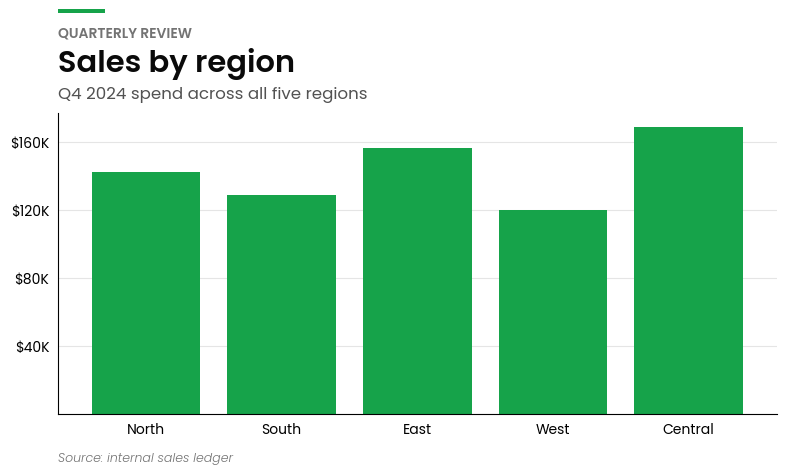

In [ ]:
ax = bar.plot(
    sales,
    x_col="store",
    value_col="spend",
    eyebrow="QUARTERLY REVIEW",
    title="Sales by region",
    subtitle="Q4 2024 spend across all five regions",
    source_text="Source: internal sales ledger",
    figsize=(8, 5),
)
shorthand(ax)
plt.show()

### Hiding the tab

The small green tab mark is on by default. Set the `plot.style.show_tab` option to `False` to suppress it project-wide. The tab's vertical slot is still reserved so the title sits at the same position whether the tab is drawn or hidden.

Set it permanently in your `openretailscience.toml`:

```toml
[plot.style]
show_tab = false
```

Or scope the change to a block with `option_context`:

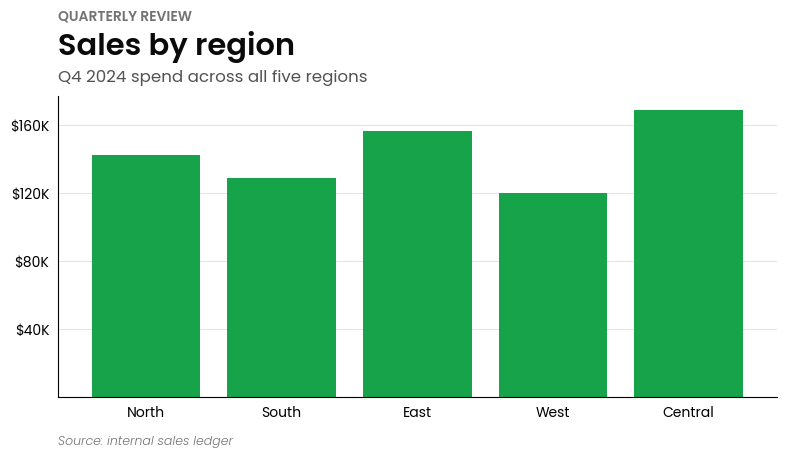

In [ ]:
with option_context("plot.style.show_tab", False):
    ax = bar.plot(
        sales,
        x_col="store",
        value_col="spend",
        eyebrow="QUARTERLY REVIEW",
        title="Sales by region",
        subtitle="Q4 2024 spend across all five regions",
        source_text="Source: internal sales ledger",
        figsize=(8, 5),
    )
    shorthand(ax)
    plt.show()

### Chrome colors

Each chrome element has its own color option. Defaults form a typographic hierarchy from darkest (title) to lightest (source/eyebrow).

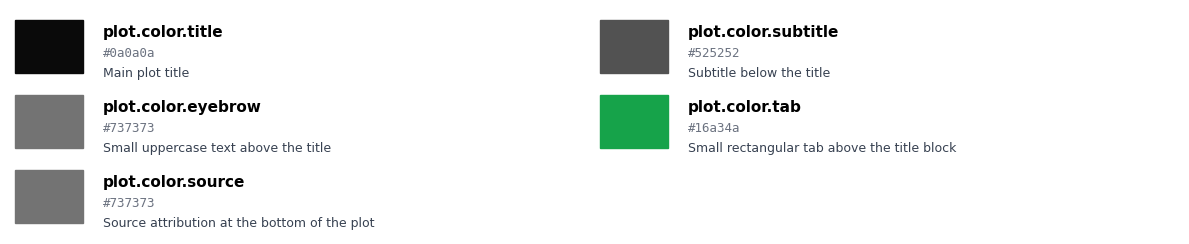

In [ ]:
chrome = [
    ("plot.color.title", get_option("plot.color.title"), "Main plot title"),
    ("plot.color.subtitle", get_option("plot.color.subtitle"), "Subtitle below the title"),
    ("plot.color.eyebrow", get_option("plot.color.eyebrow"), "Small uppercase text above the title"),
    ("plot.color.tab", get_option("plot.color.tab"), "Small rectangular tab above the title block"),
    ("plot.color.source", get_option("plot.color.source"), "Source attribution at the bottom of the plot"),
]
fig = labeled_swatches(chrome, ncols=2)
plt.show()

## Colors

Color options outside of chrome split into three groups: the **Tailwind palette** that supplies every default, **semantic colors** for data meaning (gain/loss/neutral), and **series palettes** for plots with multiple series.

### The Tailwind palette

Every color default ships from the [Tailwind CSS](https://tailwindcss.com/docs/colors) palette, exposed as `openretailscience.constants.COLORS`. Reference any shade as `COLORS["green"][500]`, or pass a hex code directly to any color option.

The hues most often referenced by defaults:

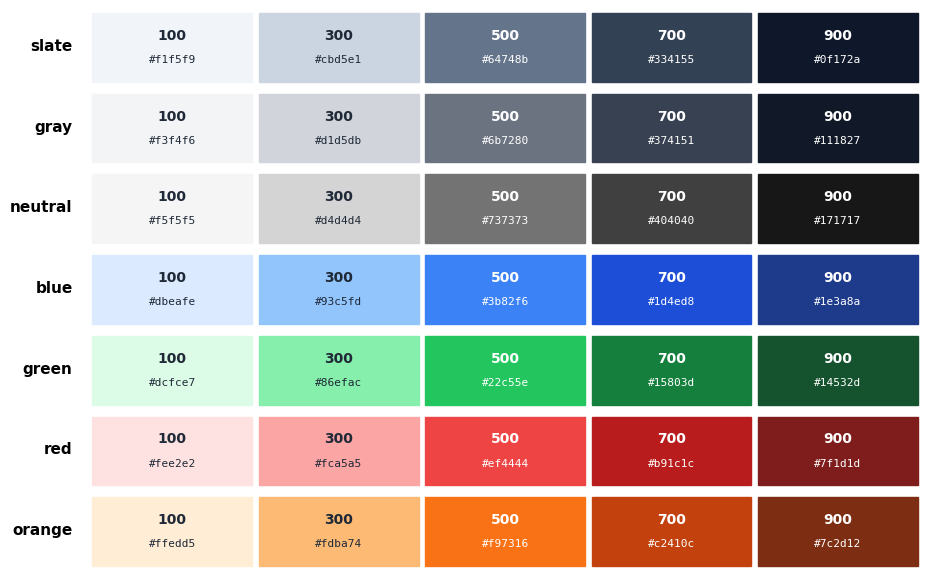

In [ ]:
fig = hue_grid(["slate", "gray", "neutral", "blue", "green", "red", "orange"])
plt.show()

### Semantic colors

These six options drive the meaning-bearing colors on a plot: gain, loss, neutral, highlight, context. Override them once and every plot in the project picks up the change.

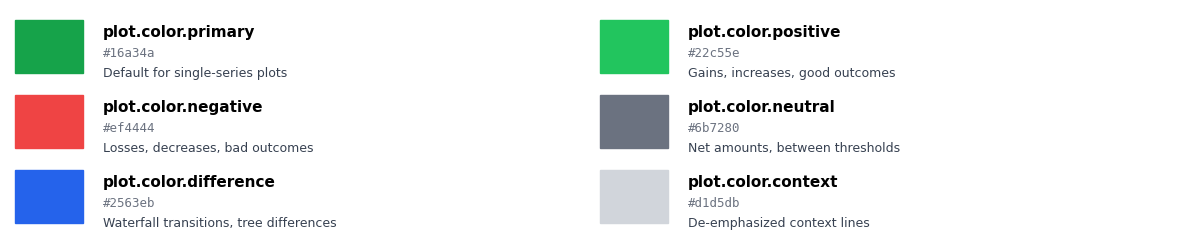

In [ ]:
semantic = [
    ("plot.color.primary", get_option("plot.color.primary"), "Default for single-series plots"),
    ("plot.color.positive", get_option("plot.color.positive"), "Gains, increases, good outcomes"),
    ("plot.color.negative", get_option("plot.color.negative"), "Losses, decreases, bad outcomes"),
    ("plot.color.neutral", get_option("plot.color.neutral"), "Net amounts, between thresholds"),
    ("plot.color.difference", get_option("plot.color.difference"), "Waterfall transitions, tree differences"),
    ("plot.color.context", get_option("plot.color.context"), "De-emphasized context lines"),
]
fig = labeled_swatches(semantic, ncols=2)
plt.show()

**Override example.** Swap `plot.color.primary` from green to a brand teal and every default-colored bar follows.

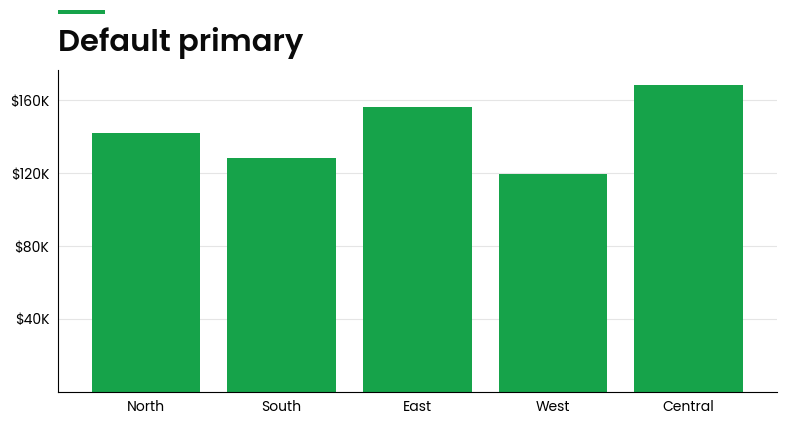

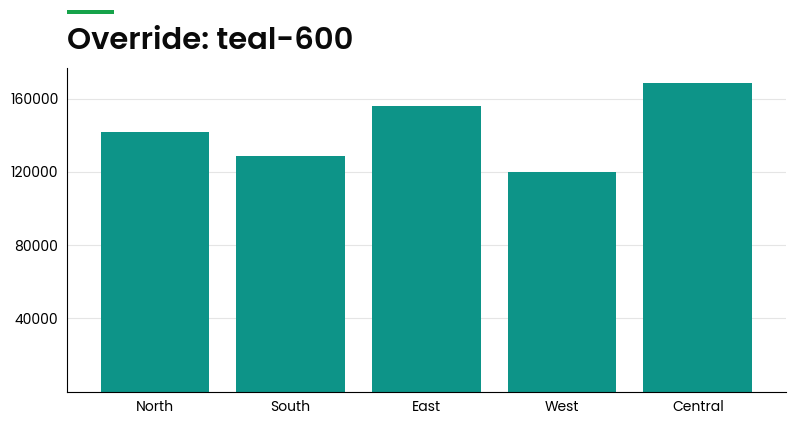

In [ ]:
ax = bar.plot(sales, x_col="store", value_col="spend", title="Default primary", figsize=(8, 4.5))
shorthand(ax)
plt.show()
with option_context("plot.color.primary", "#0d9488"):
    ax = bar.plot(sales, x_col="store", value_col="spend", title="Override: teal-600", figsize=(8, 4.5))
plt.show()

### Series palettes

Some plots draw multiple series. They reach for `multi_color_palette`, a 27-color rotation that distinguishes many unrelated series. Bars, lines, scatter groups, venns. The first 5 hues are max-separated on the hue wheel for clean reads at 3-5 series; series 10-18 fall to the lights, 19-27 to the darks.

Magnitude-ordered ramps (heatmap, cohort, period-on-period) build their colormap from the `plot.color.sequential` option instead, they don't draw from a list-valued palette.

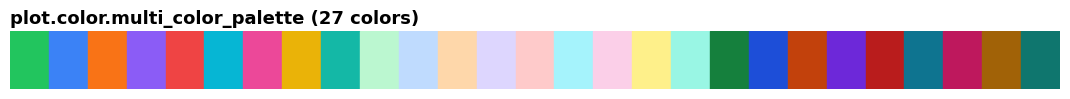

In [ ]:
fig = palette_strip(get_option("plot.color.multi_color_palette"), "plot.color.multi_color_palette (27 colors)")
plt.show()

**Override example.** Replace the multi-color rotation with a custom three-color brand palette.

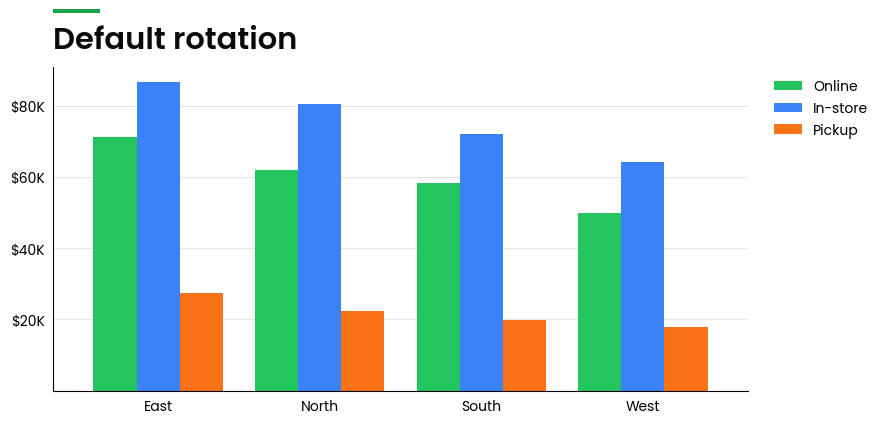

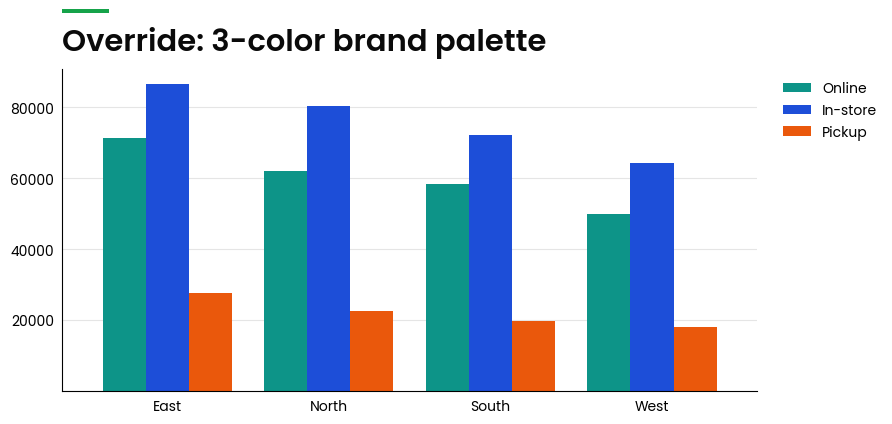

In [ ]:
ax = bar.plot(
    grouped,
    x_col="store",
    value_col=["Online", "In-store", "Pickup"],
    title="Default rotation",
    move_legend_outside=True,
    figsize=(9, 4.5),
)
shorthand(ax)
plt.show()
with option_context("plot.color.multi_color_palette", ["#0d9488", "#1d4ed8", "#ea580c"]):
    ax = bar.plot(
        grouped,
        x_col="store",
        value_col=["Online", "In-store", "Pickup"],
        title="Override: 3-color brand palette",
        move_legend_outside=True,
        figsize=(9, 4.5),
    )
plt.show()

## Fonts

Every text role on a plot has two options: a **font family** and a **size**.

### Bundled font families

OpenRetailScience ships five Poppins variants. Reference them by name in any `*_font` option, or pass a system font name (e.g., `"Arial"`, `"Times New Roman"`).

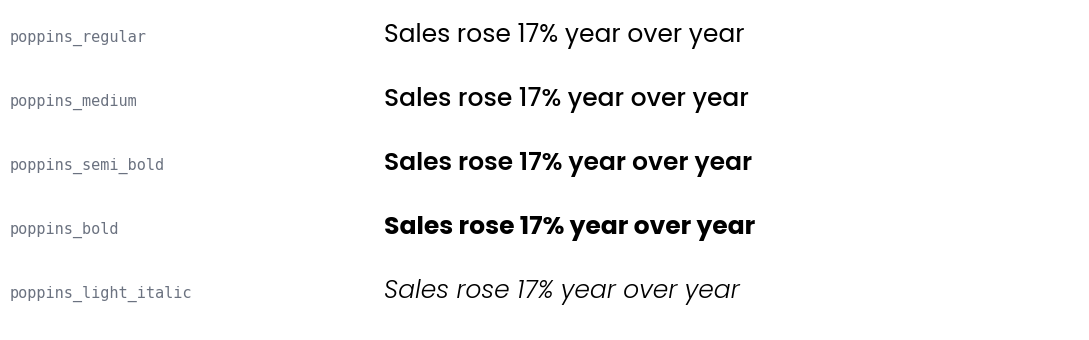

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.5))
sample = "Sales rose 17% year over year"
for i, font_name in enumerate(BUNDLED_FONTS):
    fp = get_font_properties(font_name)
    ax.text(0.0, len(BUNDLED_FONTS) - i - 0.5, font_name, fontsize=11, family="monospace", color="#6b7280")
    ax.text(0.35, len(BUNDLED_FONTS) - i - 0.5, sample, fontproperties=fp, fontsize=18)
ax.set_xlim(0, 1)
ax.set_ylim(0, len(BUNDLED_FONTS))
ax.axis("off")
plt.tight_layout()
plt.show()

### Font roles and defaults

Each role is a `(font, size)` pair. Defaults form a hierarchy: the title is largest and bolder, the source line is smallest and italicized.

| Role | Font default | Size default |
|---|---|---|
| `title` | `poppins_semi_bold` | `22.0` |
| `eyebrow` | `poppins_semi_bold` | `10.0` |
| `subtitle` | `poppins_regular` | `12.0` |
| `label` | `poppins_regular` | `11.0` |
| `tick` | `poppins_regular` | `10.0` |
| `data_label` | `poppins_medium` | `10.0` |
| `source` | `poppins_light_italic` | `9.0` |
| `legend` | `poppins_regular` | `10.0` |

Rendered at their actual defaults:

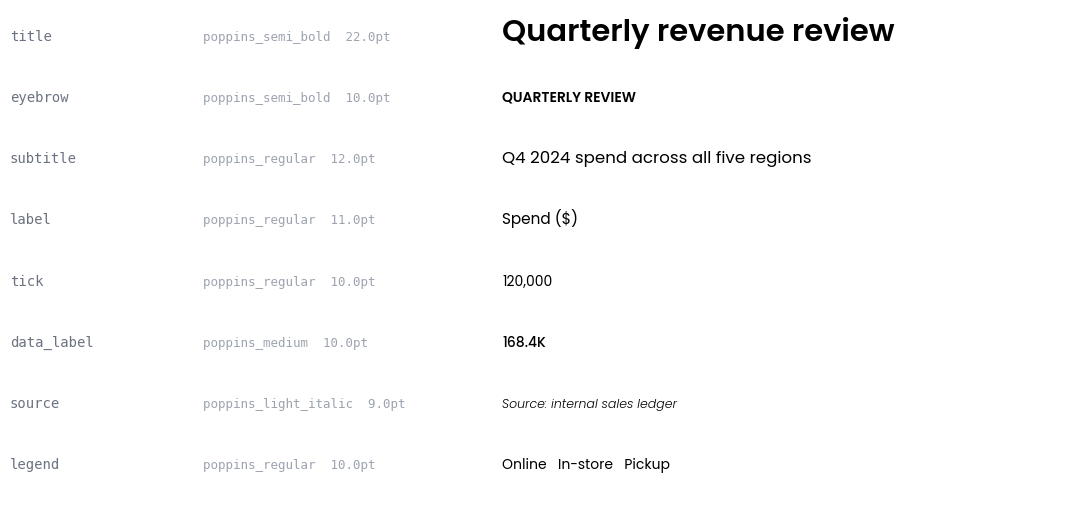

In [ ]:
roles = [
    ("title", "plot.font.title_font", "plot.font.title_size", "Quarterly revenue review"),
    ("eyebrow", "plot.font.eyebrow_font", "plot.font.eyebrow_size", "QUARTERLY REVIEW"),
    ("subtitle", "plot.font.subtitle_font", "plot.font.subtitle_size", "Q4 2024 spend across all five regions"),
    ("label", "plot.font.label_font", "plot.font.label_size", "Spend ($)"),
    ("tick", "plot.font.tick_font", "plot.font.tick_size", "120,000"),
    ("data_label", "plot.font.data_label_font", "plot.font.data_label_size", "168.4K"),
    ("source", "plot.font.source_font", "plot.font.source_size", "Source: internal sales ledger"),
    ("legend", "plot.font.legend_font", "plot.font.legend_size", "Online   In-store   Pickup"),
]

fig, ax = plt.subplots(figsize=(11, 5.2))
for i, (role, font_opt, size_opt, sample) in enumerate(roles):
    font_name = get_option(font_opt)
    size = get_option(size_opt)
    fp = get_font_properties(font_name)
    y = len(roles) - i - 0.5
    ax.text(0.0, y, role, fontsize=10, family="monospace", color="#6b7280")
    ax.text(0.18, y, f"{font_name}  {size}pt", fontsize=9, family="monospace", color="#9ca3af")
    ax.text(0.46, y, sample, fontproperties=fp, fontsize=size)
ax.set_xlim(0, 1)
ax.set_ylim(0, len(roles))
ax.axis("off")
plt.tight_layout()
plt.show()

**Override example.** Make titles smaller and lighter for a denser dashboard layout.

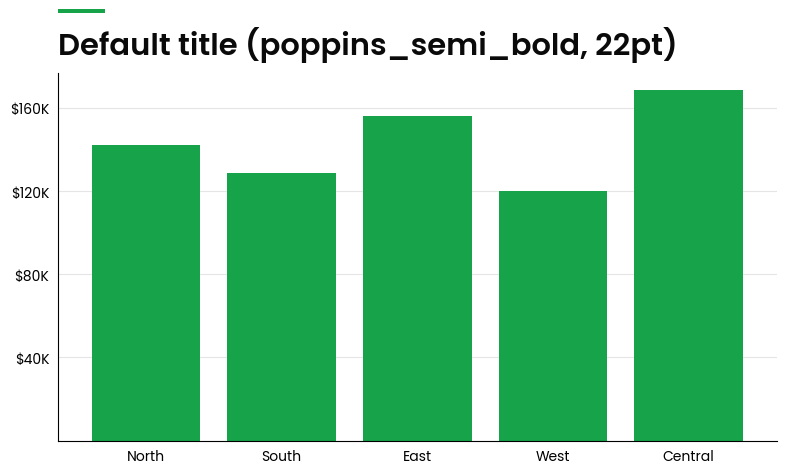

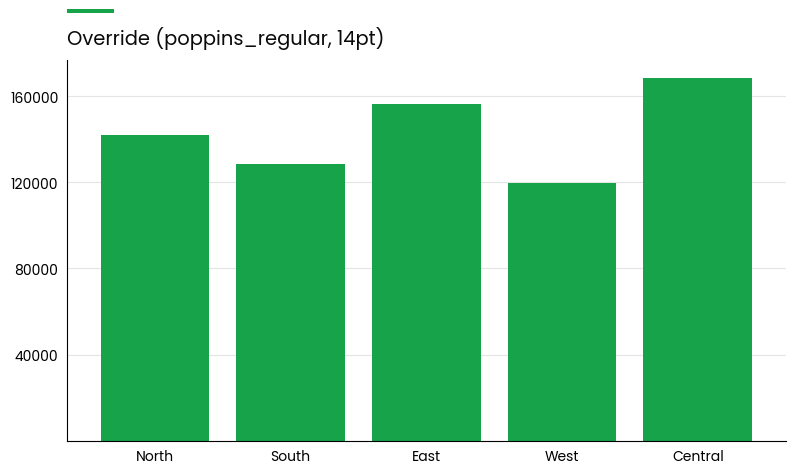

In [ ]:
ax = bar.plot(sales, x_col="store", value_col="spend", title="Default title (poppins_semi_bold, 22pt)", figsize=(8, 5))
shorthand(ax)
plt.show()
with option_context("plot.font.title_font", "poppins_regular", "plot.font.title_size", 14):
    ax = bar.plot(sales, x_col="store", value_col="spend", title="Override (poppins_regular, 14pt)", figsize=(8, 5))
plt.show()

## Spacing

Two options control padding around axis labels (in points):

- **`plot.spacing.x_label_pad`**: gap below the x-axis label (default `10`)
- **`plot.spacing.y_label_pad`**: gap left of the y-axis label (default `10`)

Increase them when axis ticks are long and crowd the label.

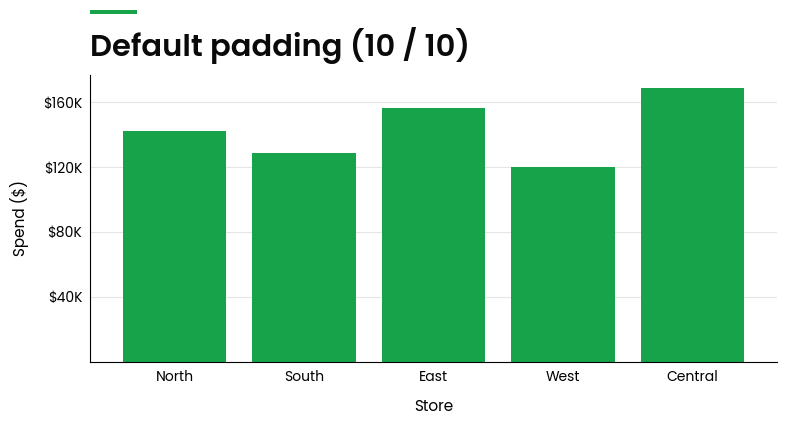

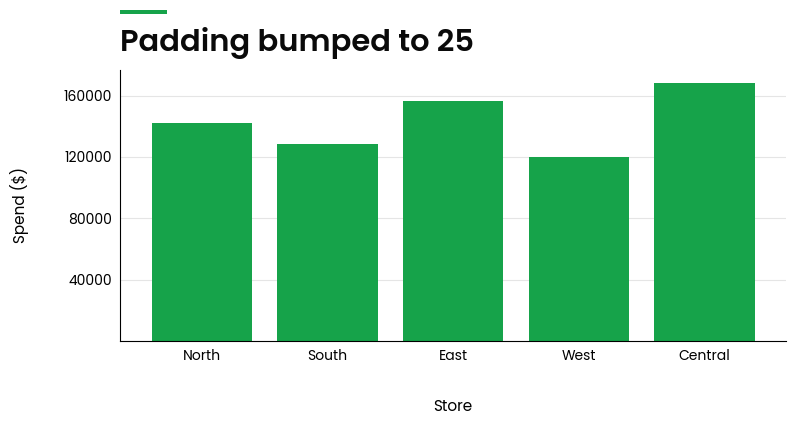

In [ ]:
ax = bar.plot(
    sales,
    x_col="store",
    value_col="spend",
    title="Default padding (10 / 10)",
    x_label="Store",
    y_label="Spend ($)",
    figsize=(8, 4.5),
)
shorthand(ax)
plt.show()
with option_context("plot.spacing.x_label_pad", 25, "plot.spacing.y_label_pad", 25):
    ax = bar.plot(
        sales,
        x_col="store",
        value_col="spend",
        title="Padding bumped to 25",
        x_label="Store",
        y_label="Spend ($)",
        figsize=(8, 4.5),
    )
plt.show()

## Style

The catch-all group: backgrounds, grid lines, axis spines, legend positioning, and cell-based plot decoration.

### Spines (axis borders)

Four boolean options for the four sides. Defaults show only the left and bottom spines: the typical clean look.

| Option | Default |
|---|---|
| `plot.style.show_top_spine` | `False` |
| `plot.style.show_right_spine` | `False` |
| `plot.style.show_bottom_spine` | `True` |
| `plot.style.show_left_spine` | `True` |

<div class="admonition note">
  <p class="admonition-title">Plots that ignore these options</p>
  <p>Heatmap and cohort plots always hide all four spines (the colored cells already define the data area). Venn diagrams, the customer decision hierarchy, and the revenue tree turn the axes off entirely. The <code>show_*_spine</code> options apply only to axis-based plots: bar, line, area, scatter, histogram, time, period-on-period, broken timeline, waterfall, index, and price.</p>
</div>

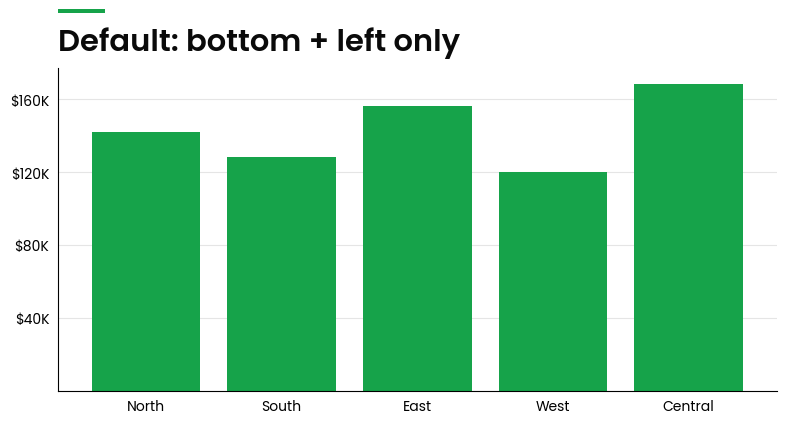

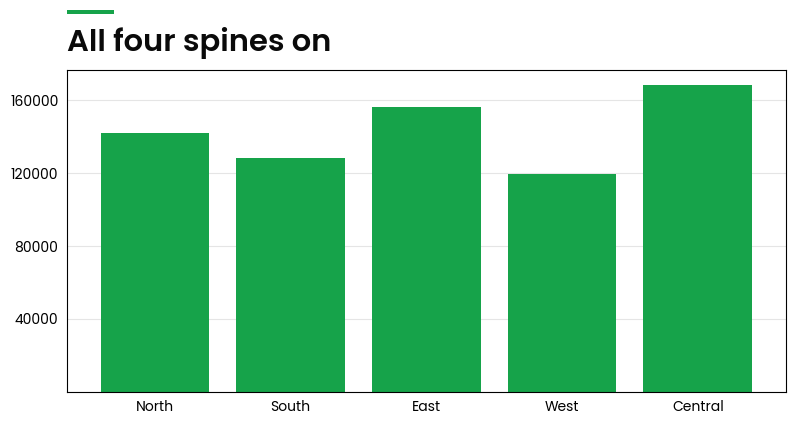

In [ ]:
ax = bar.plot(sales, x_col="store", value_col="spend", title="Default: bottom + left only", figsize=(8, 4.5))
shorthand(ax)
plt.show()
with option_context(
    "plot.style.show_top_spine",
    True,
    "plot.style.show_right_spine",
    True,
    "plot.style.show_bottom_spine",
    True,
    "plot.style.show_left_spine",
    True,
):
    ax = bar.plot(sales, x_col="store", value_col="spend", title="All four spines on", figsize=(8, 4.5))
plt.show()

### Background and grid

- **`plot.style.background_color`**: defaults to `"white"`
- **`plot.style.grid_color`**: defaults to `#e5e5e5` (Tailwind neutral-200)
- **`plot.style.grid_alpha`**: `0.0`–`1.0`, defaults to `1.0`

Use a subtle off-white with a darker grid to embed plots into a brand layout.

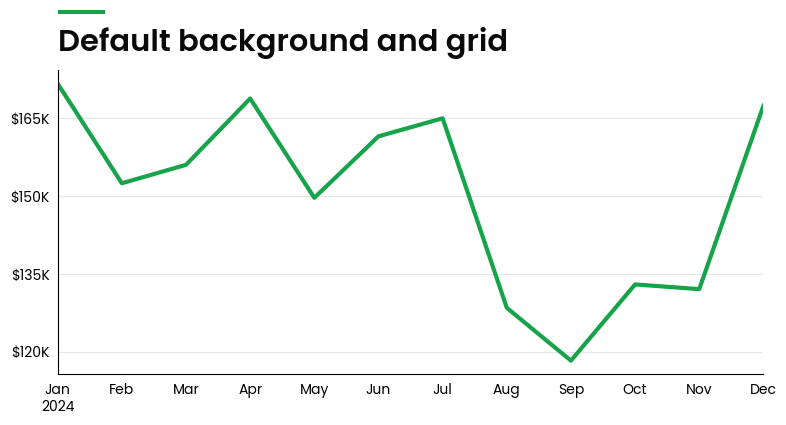

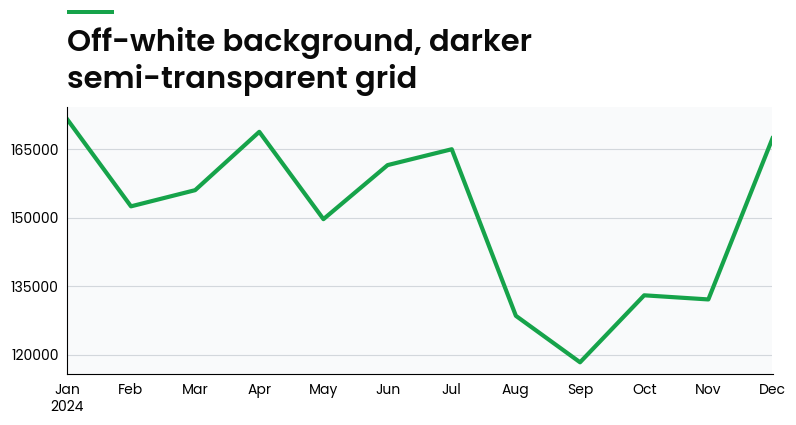

In [ ]:
ax = line.plot(monthly, x_col="month", value_col="spend", title="Default background and grid", figsize=(8, 4.5))
shorthand(ax)
plt.show()
with option_context(
    "plot.style.background_color",
    "#f9fafb",
    "plot.style.grid_color",
    "#9ca3af",
    "plot.style.grid_alpha",
    0.4,
):
    ax = line.plot(
        monthly,
        x_col="month",
        value_col="spend",
        title="Off-white background, darker semi-transparent grid",
        figsize=(8, 4.5),
    )
plt.show()

### Legend position

When a plot has multiple series, pass `move_legend_outside=True` to the plot function and control placement with two options:

- **`plot.style.legend_loc`**: anchor point on the legend box (default `"upper left"`)
- **`plot.style.legend_bbox_to_anchor`**: `[x, y]` coordinates for that anchor in axes fraction (default `[1.02, 1.0]`, just outside the right edge)

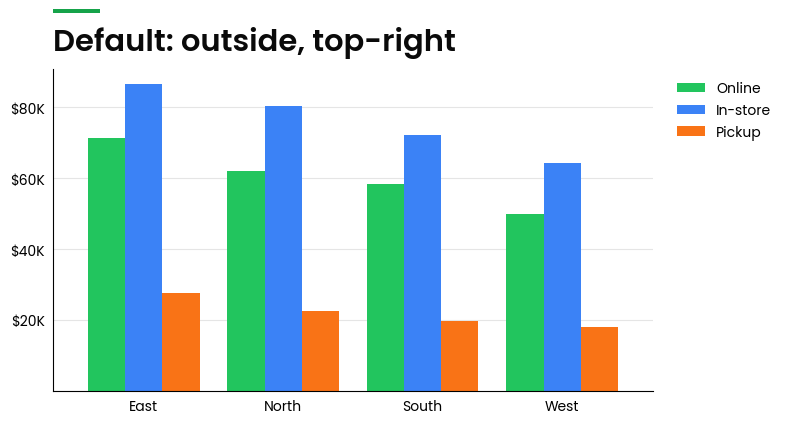

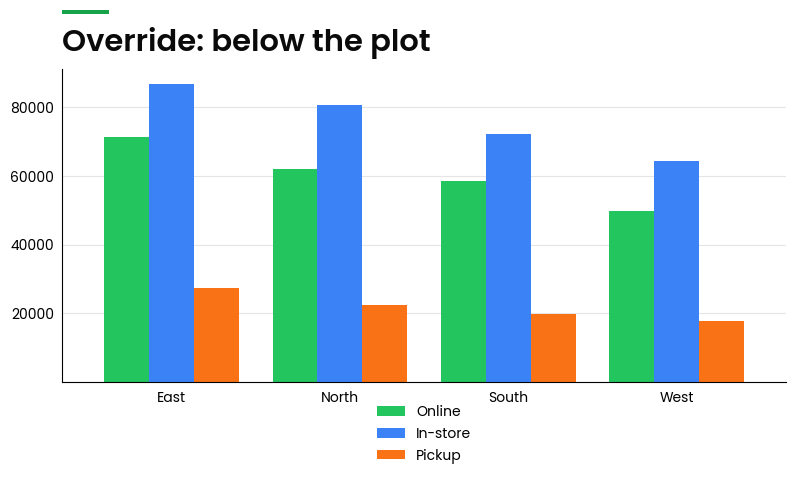

In [ ]:
ax = bar.plot(
    grouped,
    x_col="store",
    value_col=["Online", "In-store", "Pickup"],
    title="Default: outside, top-right",
    move_legend_outside=True,
    figsize=(8, 4.5),
)
shorthand(ax)
plt.show()
with option_context(
    "plot.style.legend_loc",
    "lower center",
    "plot.style.legend_bbox_to_anchor",
    [0.5, -0.3],
):
    ax = bar.plot(
        grouped,
        x_col="store",
        value_col=["Online", "In-store", "Pickup"],
        title="Override: below the plot",
        move_legend_outside=True,
        figsize=(8, 5),
    )
plt.show()

### X-tick label handling

Two options control how categorical x-tick labels are placed when they would otherwise overlap:

- **`plot.style.auto_rotate_x_ticks`**: defaults to `True`
- **`plot.style.auto_wrap_x_ticks`**: defaults to `True`

Pandas' `df.plot(kind="bar")` rotates x-tick labels to 90° even for short categories like "North"/"South". With auto-rotate enabled, OpenRetailScience instead measures whether the labels would overlap horizontally and only escalates when needed. With auto-wrap enabled, multi-word labels first try a balanced two-line split (e.g. `"Camden High St"` → `"Camden"` + `"High St"`) before falling back to rotation.

**The four states.** The engine tries each state in order and stops at the first one that fits:

| Order | State | Skipped when |
|---|---|---|
| 1 | **0° horizontal**, original text | — (always tried first) |
| 2 | **0° horizontal, wrapped onto two balanced lines** | label is single-word, or `auto_wrap_x_ticks=False` |
| 3 | **45° rotation**, right-anchored | — |
| 4 | **90° rotation**, right-anchored | — (terminal state) |

**Example: long multi-word labels.** Auto-wrap turns these UK regions into two-line labels rather than rotating them.

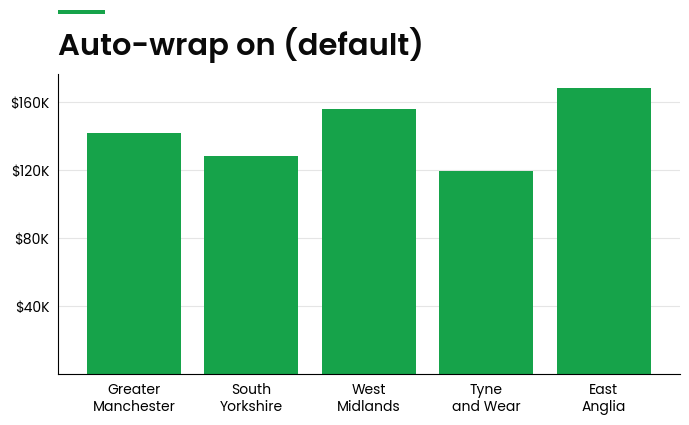

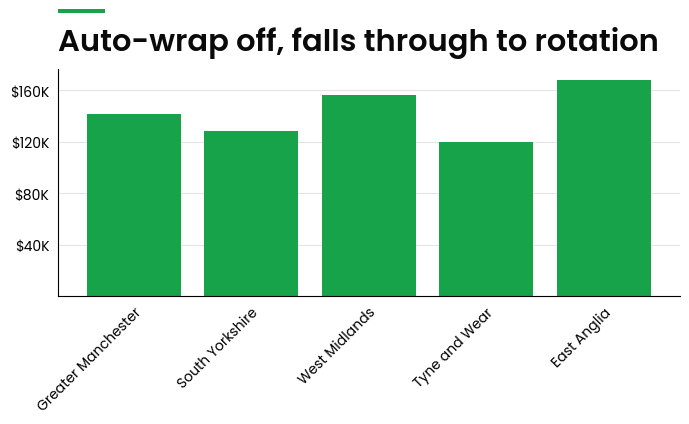

In [ ]:
regions = pd.DataFrame(
    {
        "region": ["Greater Manchester", "South Yorkshire", "West Midlands", "Tyne and Wear", "East Anglia"],
        "spend": [142_000, 128_500, 156_200, 119_800, 168_400],
    }
)
ax = bar.plot(regions, x_col="region", value_col="spend", title="Auto-wrap on (default)", figsize=(7, 4.5))
shorthand(ax)
plt.show()
with option_context("plot.style.auto_wrap_x_ticks", False):
    ax = bar.plot(
        regions, x_col="region", value_col="spend", title="Auto-wrap off, falls through to rotation", figsize=(7, 4.5)
    )
    shorthand(ax)
    plt.show()

**A note on detection.** The overlap check renders the labels with the candidate state, measures their pixel bounding boxes, and flags any pair of adjacent labels whose horizontal extents touch within ~4px. The check runs *after* the chrome layout pass and after legends are placed outside, so the axes width is the final rendered width — labels picked at the default `figsize` may pick a different state at a wider or narrower one.

**Disabling auto-rotate** keeps matplotlib's (or pandas') native rotation choice — useful when you want consistent layout across a series of charts regardless of label length:

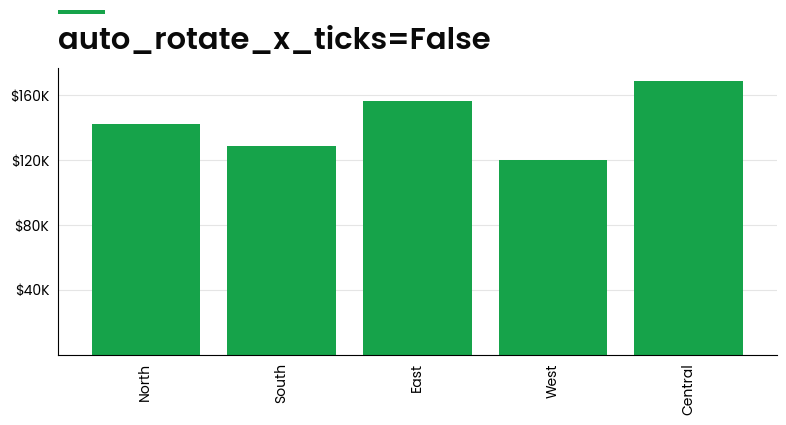

In [ ]:
with option_context("plot.style.auto_rotate_x_ticks", False):
    ax = bar.plot(sales, x_col="store", value_col="spend", title="auto_rotate_x_ticks=False", figsize=(8, 4.5))
    shorthand(ax)
    plt.show()

### Cell-based plots

Heatmaps and cohort charts draw a grid of cells. Two options control their decoration:

- **`plot.style.cell_corner_radius`**: rounded corner size in cell-size units (default `0.05`). Set to `0` for hard rectangles.
- **`plot.style.cell_gap`**: visible gap between cells in points (default `3.0`). Drawn as a background-colored edge.

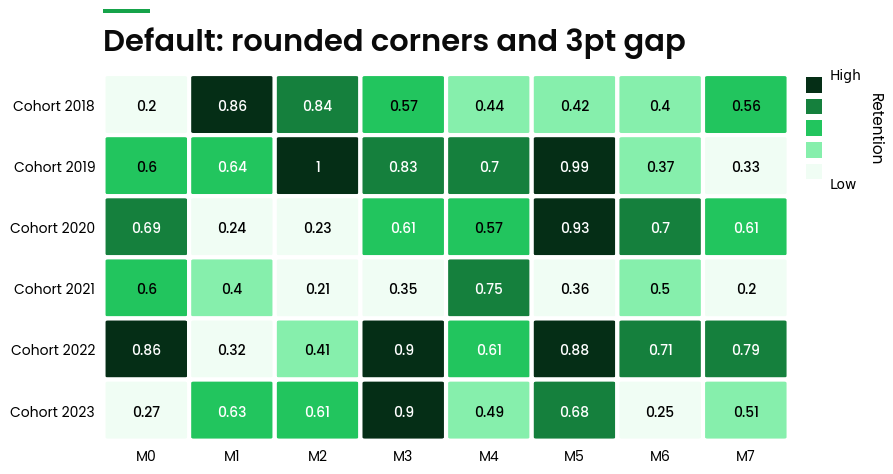

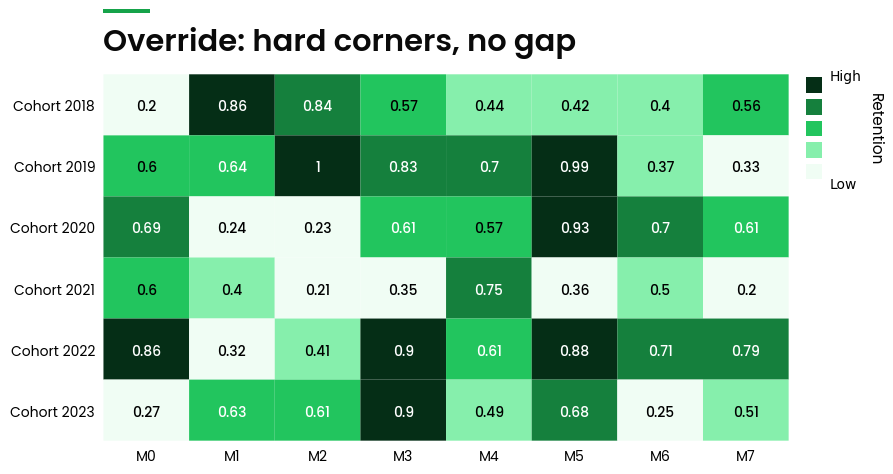

In [ ]:
retention = pd.DataFrame(
    rng.uniform(0.2, 1.0, size=(6, 8)).round(2),
    index=[f"Cohort {y}" for y in range(2018, 2024)],
    columns=[f"M{i}" for i in range(8)],
)

heatmap.plot(retention, cbar_label="Retention", title="Default: rounded corners and 3pt gap", figsize=(9, 5))
plt.show()
with option_context("plot.style.cell_corner_radius", 0.0, "plot.style.cell_gap", 0.0):
    heatmap.plot(retention, cbar_label="Retention", title="Override: hard corners, no gap", figsize=(9, 5))
plt.show()

## Where to next

- Browse rendered examples for every plot type in the [Plot Gallery](../../gallery/).
- Learn how options resolve across TOML files, `set_option`, and `option_context` in the [Options & Configuration](../options_guide/) guide.
- See the full machine-readable list of options on the [Options API reference](../../api/options/).